In [35]:
# ============================================
# 01. Imports
# ============================================

import sys
import gzip
import re
import warnings
from pathlib import Path
import subprocess

import numpy as np
import pandas as pd

import scipy
from scipy.stats import pearsonr, spearmanr

import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display


# --------------------------------------------
# Notebook behavior
# --------------------------------------------

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
)


# --------------------------------------------
# Package versions
# --------------------------------------------

print(f"Python      : {sys.version.split()[0]}")
print(f"NumPy       : {np.__version__}")
print(f"pandas      : {pd.__version__}")
print(f"SciPy       : {scipy.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"Matplotlib  : {mpl.__version__}")

Python      : 3.11.15
NumPy       : 2.4.6
pandas      : 2.3.3
SciPy       : 1.17.1
scikit-learn: 1.9.0
Matplotlib  : 3.10.9


In [3]:
# ============================================
# Global plotting configuration
# ============================================

_PLOT_CFG = {
    "fig_w": 6.0,
    "fig_h": 5.0,
    "dpi": 300,
}


def set_plot_style(
    *,
    # Fonts
    base_fontsize=11,
    title_fontsize=14,
    label_fontsize=13,
    tick_fontsize=11,
    legend_fontsize=11,

    dpi=300,

    axes_linewidth=1.2,
    spines_top=True,
    spines_right=True,

    tick_size_major=6,
    tick_dir="out",

    grid=False,

    fig_w=6.0,
    fig_h=5.0,
):

    sns.set_style("ticks")

    mpl.rcParams.update({

        # =====================================
        # Fonts
        # =====================================
        "font.family": "DejaVu Sans",
        "font.size": base_fontsize,

        "axes.titlesize": title_fontsize,
        "axes.labelsize": label_fontsize,

        "xtick.labelsize": tick_fontsize,
        "ytick.labelsize": tick_fontsize,

        "legend.fontsize": legend_fontsize,

        # =====================================
        # Figure
        # =====================================
        "figure.dpi": dpi,
        "savefig.dpi": dpi,

        # =====================================
        # Axes
        # =====================================
        "axes.linewidth": axes_linewidth,
        "axes.spines.top": spines_top,
        "axes.spines.right": spines_right,
        "axes.grid": grid,
        "axes.axisbelow": True,

        # =====================================
        # Ticks
        # =====================================
        "xtick.major.size": tick_size_major,
        "ytick.major.size": tick_size_major,
        "xtick.direction": tick_dir,
        "ytick.direction": tick_dir,

        # =====================================
        # Legend
        # =====================================
        "legend.frameon": False,

        # =====================================
        # Save figure
        # =====================================
        "savefig.bbox": "tight",
        "savefig.transparent": False,
    })

    _PLOT_CFG.update({
        "fig_w": fig_w,
        "fig_h": fig_h,
        "dpi": dpi,
    })


def make_fig(
    w=None,
    h=None,
    dpi=None,
):
    W = float(w) if w is not None else _PLOT_CFG["fig_w"]
    H = float(h) if h is not None else _PLOT_CFG["fig_h"]
    D = dpi if dpi is not None else _PLOT_CFG["dpi"]

    fig, ax = plt.subplots(
        figsize=(W, H),
        dpi=D,
    )

    return fig, ax


set_plot_style()

In [4]:
# ============================================
# 02. Project paths
# ============================================

PROJECT_DIR = Path("/mnt/d/Ibnu/riboseq/AT")

# --------------------------------------------
# nf-core/riboseq results
# --------------------------------------------

NFCORE_DIR = PROJECT_DIR / "nfcore" / "full"

QUANT_DIR = NFCORE_DIR / "quantification"
RIBOWALTZ_DIR = NFCORE_DIR / "ribowaltz"
ALIGNMENT_DIR = NFCORE_DIR / "alignment"
MULTIQC_DIR = NFCORE_DIR / "multiqc"

# --------------------------------------------
# Post-processing
# --------------------------------------------

POSTPROCESS_DIR = PROJECT_DIR / "postprocess"

ANNOTATION_DIR = POSTPROCESS_DIR / "arabidopsis_thaliana" / "annotation"
PROCESSED_DIR = POSTPROCESS_DIR / "arabidopsis_thaliana" / "processed"
FIGURE_DIR = POSTPROCESS_DIR / "arabidopsis_thaliana" / "figures"
TABLE_DIR = POSTPROCESS_DIR / "arabidopsis_thaliana" / "tables"

# --------------------------------------------
# Create directories if needed
# --------------------------------------------

for directory in [
    POSTPROCESS_DIR,
    ANNOTATION_DIR,
    PROCESSED_DIR,
    FIGURE_DIR,
    TABLE_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

# --------------------------------------------
# Display
# --------------------------------------------

print("Project directory")
print(PROJECT_DIR)

print("\nOutput directories")
print(f"Annotation : {ANNOTATION_DIR}")
print(f"Processed  : {PROCESSED_DIR}")
print(f"Figures    : {FIGURE_DIR}")
print(f"Tables     : {TABLE_DIR}")

Project directory
/mnt/d/Ibnu/riboseq/AT

Output directories
Annotation : /mnt/d/Ibnu/riboseq/AT/postprocess/arabidopsis_thaliana/annotation
Processed  : /mnt/d/Ibnu/riboseq/AT/postprocess/arabidopsis_thaliana/processed
Figures    : /mnt/d/Ibnu/riboseq/AT/postprocess/arabidopsis_thaliana/figures
Tables     : /mnt/d/Ibnu/riboseq/AT/postprocess/arabidopsis_thaliana/tables


In [5]:
# ============================================
# 03.1 Input files
# ============================================

# --------------------------------------------
# Quantification
# --------------------------------------------

TX2GENE_FILE = (
    QUANT_DIR /
    "tx2gene.tsv"
)

TRANSCRIPT_COUNT_FILE = (
    QUANT_DIR /
    "salmon" /
    "salmon.merged.transcript_counts.tsv"
)

TRANSCRIPT_TPM_FILE = (
    QUANT_DIR /
    "salmon" /
    "salmon.merged.transcript_tpm.tsv"
)


# --------------------------------------------
# riboWaltz
# --------------------------------------------

PSITE_FILE = (
    RIBOWALTZ_DIR /
    "RIBO_FULL.psite.tsv.gz"
)

PSITE_OFFSET_FILE = (
    RIBOWALTZ_DIR /
    "RIBO_FULL.psite_offset.tsv.gz"
)

BEST_OFFSET_FILE = (
    RIBOWALTZ_DIR /
    "RIBO_FULL.best_offset.txt"
)

CODON_COVERAGE_FILE = (
    RIBOWALTZ_DIR /
    "RIBO_FULL.codon_coverage_psite.tsv.gz"
)

CDS_COVERAGE_FILE = (
    RIBOWALTZ_DIR /
    "RIBO_FULL.cds_coverage_psite.tsv.gz"
)

CDS_EXTENDED_COVERAGE_FILE = (
    RIBOWALTZ_DIR /
    "RIBO_FULL.cds_plus42nt_minus27nt_coverage_psite.tsv.gz"
)


# --------------------------------------------
# Reference genome
# --------------------------------------------

REFERENCE_FASTA = (
    ANNOTATION_DIR /
    "at.fa"
)

REFERENCE_GFF3 = (
    ANNOTATION_DIR /
    "at.gff3"
)

TRANSCRIPT_FASTA = (
    ANNOTATION_DIR /
    "transcripts.fa"
)

CDS_FASTA = (
    ANNOTATION_DIR /
    "cds.fa"
)


# --------------------------------------------
# Annotation
# --------------------------------------------

CDS_SAF = (
    ANNOTATION_DIR /
    "CDS.saf"
)

UTR5_SAF = (
    ANNOTATION_DIR /
    "five_prime_UTR.saf"
)

UTR3_SAF = (
    ANNOTATION_DIR /
    "three_prime_UTR.saf"
)

In [6]:
# ============================================
# 03.2 Verify nf-core input files
# ============================================

nfcore_input_files = {
    "tx2gene": TX2GENE_FILE,
    "transcript counts": TRANSCRIPT_COUNT_FILE,
    "transcript TPM": TRANSCRIPT_TPM_FILE,
    "P-site table": PSITE_FILE,
    "P-site offsets": PSITE_OFFSET_FILE,
    "best offset": BEST_OFFSET_FILE,
    "codon coverage": CODON_COVERAGE_FILE,
    "CDS coverage": CDS_COVERAGE_FILE,
    "extended CDS coverage": CDS_EXTENDED_COVERAGE_FILE,
}

missing_files = []

for name, path in nfcore_input_files.items():
    if path.exists():
        print(f"OK      {name}: {path}")
    else:
        print(f"MISSING {name}: {path}")
        missing_files.append(path)

if missing_files:
    raise FileNotFoundError(
        "Some required nf-core output files are missing."
    )

print("\nAll required nf-core output files were found.")

OK      tx2gene: /mnt/d/Ibnu/riboseq/AT/nfcore/full/quantification/tx2gene.tsv
OK      transcript counts: /mnt/d/Ibnu/riboseq/AT/nfcore/full/quantification/salmon/salmon.merged.transcript_counts.tsv
OK      transcript TPM: /mnt/d/Ibnu/riboseq/AT/nfcore/full/quantification/salmon/salmon.merged.transcript_tpm.tsv
OK      P-site table: /mnt/d/Ibnu/riboseq/AT/nfcore/full/ribowaltz/RIBO_FULL.psite.tsv.gz
OK      P-site offsets: /mnt/d/Ibnu/riboseq/AT/nfcore/full/ribowaltz/RIBO_FULL.psite_offset.tsv.gz
OK      best offset: /mnt/d/Ibnu/riboseq/AT/nfcore/full/ribowaltz/RIBO_FULL.best_offset.txt
OK      codon coverage: /mnt/d/Ibnu/riboseq/AT/nfcore/full/ribowaltz/RIBO_FULL.codon_coverage_psite.tsv.gz
OK      CDS coverage: /mnt/d/Ibnu/riboseq/AT/nfcore/full/ribowaltz/RIBO_FULL.cds_coverage_psite.tsv.gz
OK      extended CDS coverage: /mnt/d/Ibnu/riboseq/AT/nfcore/full/ribowaltz/RIBO_FULL.cds_plus42nt_minus27nt_coverage_psite.tsv.gz

All required nf-core output files were found.


In [7]:
# ============================================
# 03.3 Load nf-core outputs
# ============================================

# --------------------------------------------
# Transcript quantification
# --------------------------------------------

tx2gene = pd.read_csv(
    TX2GENE_FILE,
    sep="\t",
)

transcript_counts = pd.read_csv(
    TRANSCRIPT_COUNT_FILE,
    sep="\t",
)

transcript_tpm = pd.read_csv(
    TRANSCRIPT_TPM_FILE,
    sep="\t",
)


# --------------------------------------------
# riboWaltz outputs
# --------------------------------------------

psite = pd.read_csv(
    PSITE_FILE,
    sep="\t",
)

psite_offset = pd.read_csv(
    PSITE_OFFSET_FILE,
    sep="\t",
)

best_offset = pd.read_csv(
    BEST_OFFSET_FILE,
    sep="\t",
)

codon_coverage = pd.read_csv(
    CODON_COVERAGE_FILE,
    sep="\t",
)

cds_coverage = pd.read_csv(
    CDS_COVERAGE_FILE,
    sep="\t",
)

cds_extended_coverage = pd.read_csv(
    CDS_EXTENDED_COVERAGE_FILE,
    sep="\t",
)

/tmp/ipykernel_77269/2934591936.py:29: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  psite = pd.read_csv(


In [8]:
# ============================================
# 03.4 Dataset overview
# ============================================

datasets = {
    "tx2gene": tx2gene,
    "transcript_counts": transcript_counts,
    "transcript_tpm": transcript_tpm,
    "psite": psite,
    "psite_offset": psite_offset,
    "best_offset": best_offset,
    "codon_coverage": codon_coverage,
    "cds_coverage": cds_coverage,
    "cds_extended_coverage": cds_extended_coverage,
}

summary = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()],
})

display(summary)

,Dataset,Rows,Columns
0,tx2gene,59478,3
1,transcript_counts,59051,4
2,transcript_tpm,59051,4
3,psite,20461066,12
4,psite_offset,27,9
5,best_offset,1,3
6,codon_coverage,25289212,7
7,cds_coverage,48359,3
8,cds_extended_coverage,48323,3


In [9]:
# ============================================
# 04.1 Standardize quantification tables
# ============================================

# --------------------------------------------
# Inspect original columns
# --------------------------------------------

print("tx2gene columns:")
print(tx2gene.columns.tolist())

print("\ntranscript_counts columns:")
print(transcript_counts.columns.tolist())

print("\ntranscript_tpm columns:")
print(transcript_tpm.columns.tolist())


# --------------------------------------------
# Standardize column names
# --------------------------------------------

counts = transcript_counts.rename(columns={
    "tx": "transcript_id",
    "RIBO_FULL": "ribo_read_count",
    "RNA_FULL": "rna_read_count",
}).copy()

tpm = transcript_tpm.rename(columns={
    "tx": "transcript_id",
    "RIBO_FULL": "ribo_tpm",
    "RNA_FULL": "rna_tpm",
}).copy()


# --------------------------------------------
# Keep only columns needed downstream
# --------------------------------------------

counts = counts[[
    "transcript_id",
    "gene_id",
    "ribo_read_count",
    "rna_read_count",
]].copy()

tpm = tpm[[
    "transcript_id",
    "gene_id",
    "ribo_tpm",
    "rna_tpm",
]].copy()


# --------------------------------------------
# Basic checks
# --------------------------------------------

print("\nPrepared table shapes:")
print("tx2gene:", tx2gene.shape)
print("counts :", counts.shape)
print("TPM    :", tpm.shape)

print("\nDuplicate transcript IDs:")
print(
    "tx2gene:",
    tx2gene["transcript_id"].duplicated().sum(),
)
print(
    "counts :",
    counts["transcript_id"].duplicated().sum(),
)
print(
    "TPM    :",
    tpm["transcript_id"].duplicated().sum(),
)


display(tx2gene.head())
display(counts.head())
display(tpm.head())

tx2gene columns:
['transcript_id', 'gene_id', 'gene_name']

transcript_counts columns:
['tx', 'gene_id', 'RIBO_FULL', 'RNA_FULL']

transcript_tpm columns:
['tx', 'gene_id', 'RIBO_FULL', 'RNA_FULL']

Prepared table shapes:
tx2gene: (59478, 3)
counts : (59051, 4)
TPM    : (59051, 4)

Duplicate transcript IDs:
tx2gene: 0
counts : 0
TPM    : 0


,transcript_id,gene_id,gene_name
0,AT1G01010.1,AT1G01010,AT1G01010
1,AT1G01020.2,AT1G01020,AT1G01020
2,AT1G01020.6,AT1G01020,AT1G01020
3,AT1G01020.1,AT1G01020,AT1G01020
4,AT1G01020.3,AT1G01020,AT1G01020


,transcript_id,gene_id,ribo_read_count,rna_read_count
0,AT1G01010.1,AT1G01010,24.0,157.000
1,AT1G01020.2,AT1G01020,14.0,211.134
2,AT1G01020.6,AT1G01020,0.0,12.734
3,AT1G01020.1,AT1G01020,0.0,347.194
4,AT1G01020.3,AT1G01020,0.0,47.368


,transcript_id,gene_id,ribo_tpm,rna_tpm
0,AT1G01010.1,AT1G01010,0.107730,2.876792
1,AT1G01020.2,AT1G01020,0.107966,6.646622
2,AT1G01020.6,AT1G01020,0.000000,0.483483
3,AT1G01020.1,AT1G01020,0.000000,8.478478
4,AT1G01020.3,AT1G01020,0.000000,1.066754


In [10]:
# ============================================
# 04.2 Merge transcript quantification
# ============================================

# --------------------------------------------
# Merge annotation with read counts
# --------------------------------------------

master = (
    tx2gene.merge(
        counts,
        on=[
            "transcript_id",
            "gene_id",
        ],
        how="left",
    )
)

# --------------------------------------------
# Merge TPM
# --------------------------------------------

master = (
    master.merge(
        tpm[
            [
                "transcript_id",
                "ribo_tpm",
                "rna_tpm",
            ]
        ],
        on="transcript_id",
        how="left",
    )
)

print(master.shape)

display(master.head())

(59478, 7)


,transcript_id,gene_id,gene_name,ribo_read_count,rna_read_count,ribo_tpm,rna_tpm
0,AT1G01010.1,AT1G01010,AT1G01010,24.0,157.000,0.107730,2.876792
1,AT1G01020.2,AT1G01020,AT1G01020,14.0,211.134,0.107966,6.646622
2,AT1G01020.6,AT1G01020,AT1G01020,0.0,12.734,0.000000,0.483483
3,AT1G01020.1,AT1G01020,AT1G01020,0.0,347.194,0.000000,8.478478
4,AT1G01020.3,AT1G01020,AT1G01020,0.0,47.368,0.000000,1.066754


In [11]:
# ============================================
# 04.3 Quantification summary
# ============================================

summary = pd.DataFrame({
    "Metric": [
        "Annotated transcripts",
        "Quantified transcripts",
        "Missing counts",
        "Missing TPM",
    ],
    "Value": [
        len(master),
        master["ribo_read_count"].notna().sum(),
        master["ribo_read_count"].isna().sum(),
        master["ribo_tpm"].isna().sum(),
    ],
})

display(summary)

,Metric,Value
0,Annotated transcripts,59478
1,Quantified transcripts,59051
2,Missing counts,427
3,Missing TPM,427


In [12]:
# # ============================================
# # 04.4 Missing-value summary
# # ============================================

# missing_summary = (
#     master
#     .isna()
#     .sum()
#     .rename("Missing")
#     .to_frame()
# )

# missing_summary["Percentage"] = (
#     missing_summary["Missing"]
#     / len(master)
#     * 100
# )

# display(missing_summary)

In [14]:
# ============================================
# 04.5 Read-count filtering
# ============================================

master_filtered = (
    master
    .dropna(
        subset=[
            "ribo_read_count",
            "rna_read_count",
            "ribo_tpm",
            "rna_tpm",
        ]
    )
    .copy()
)

master_filtered = master_filtered.loc[
    (master_filtered["ribo_read_count"] > 0)
    &
    (master_filtered["rna_read_count"] > 0)
].copy()

summary = pd.DataFrame({
    "Metric": [
        "Annotated transcripts",
        "Quantified transcripts",
        "Filtered transcripts",
    ],
    "Value": [
        len(master),
        master["ribo_read_count"].notna().sum(),
        len(master_filtered),
    ],
})

display(summary)

,Metric,Value
0,Annotated transcripts,59478
1,Quantified transcripts,59051
2,Filtered transcripts,22306


In [16]:
# # ============================================
# # 04.6 Save processed quantification table
# # ============================================

# master_filtered.to_csv(
#     PROCESSED_DIR / "master_quantification.tsv.gz",
#     sep="\t",
#     index=False,
#     compression="gzip",
# )

# print(
#     "Saved:",
#     PROCESSED_DIR / "master_quantification.tsv.gz"
# )

## 05 Compositional linear model and residual TE

Model CLR-transformed ribosome occupancy as a function of CLR-transformed RNA abundance.

Translation efficiency is defined as the residual:

\[
TE = \text{observed Ribo CLR} - \text{predicted Ribo CLR}
\]

Positive TE indicates more ribosome occupancy than expected from RNA abundance, while negative TE indicates less.

In [17]:
# ============================================
# 05.1 Centered log-ratio transformation
# ============================================

master_te = master_filtered.copy()

master_te["rna_clr"] = (
    np.log(master_te["rna_read_count"])
    - np.log(master_te["rna_read_count"]).mean()
)

master_te["ribo_clr"] = (
    np.log(master_te["ribo_read_count"])
    - np.log(master_te["ribo_read_count"]).mean()
)

display(
    master_te[
        [
            "transcript_id",
            "rna_read_count",
            "ribo_read_count",
            "rna_clr",
            "ribo_clr",
        ]
    ].head()
)

,transcript_id,rna_read_count,ribo_read_count,rna_clr,ribo_clr
0,AT1G01010.1,157.000,24.00,-0.930637,-0.390050
1,AT1G01020.2,211.134,14.00,-0.634390,-0.929047
9,AT1G01030.2,19.582,7.00,-3.012272,-1.622194
10,AT1G01040.1,2345.008,48.00,1.773161,0.303097
15,AT1G01050.1,2517.218,197.02,1.844027,1.715201


In [18]:
# ============================================
# 05.2 Compositional linear model and residual TE
# ============================================

X = master_te[["rna_clr"]]
y = master_te["ribo_clr"]

te_model = LinearRegression()
te_model.fit(X, y)

master_te["predicted_ribo_clr"] = (
    te_model.predict(X)
)

master_te["TE"] = (
    master_te["ribo_clr"]
    - master_te["predicted_ribo_clr"]
)

print(
    "Regression intercept:",
    f"{te_model.intercept_:.6f}",
)

print(
    "Regression slope:",
    f"{te_model.coef_[0]:.6f}",
)

display(
    master_te[[
        "transcript_id",
        "gene_id",
        "rna_read_count",
        "ribo_read_count",
        "rna_clr",
        "ribo_clr",
        "predicted_ribo_clr",
        "TE",
    ]].head()
)

Regression intercept: 0.000000
Regression slope: 0.674890


,transcript_id,gene_id,rna_read_count,ribo_read_count,rna_clr,ribo_clr,predicted_ribo_clr,TE
0,AT1G01010.1,AT1G01010,157.000,24.00,-0.930637,-0.390050,-0.628078,0.238028
1,AT1G01020.2,AT1G01020,211.134,14.00,-0.634390,-0.929047,-0.428144,-0.500903
9,AT1G01030.2,AT1G01030,19.582,7.00,-3.012272,-1.622194,-2.032954,0.410760
10,AT1G01040.1,AT1G01040,2345.008,48.00,1.773161,0.303097,1.196689,-0.893593
15,AT1G01050.1,AT1G01050,2517.218,197.02,1.844027,1.715201,1.244516,0.470685


In [19]:
# ============================================
# 05.3 Regression quality assessment
# ============================================

pearson_r, pearson_p = pearsonr(
    master_te["rna_clr"],
    master_te["ribo_clr"],
)

spearman_r, spearman_p = spearmanr(
    master_te["rna_clr"],
    master_te["ribo_clr"],
)

r2 = r2_score(
    master_te["ribo_clr"],
    master_te["predicted_ribo_clr"],
)

rmse = np.sqrt(
    mean_squared_error(
        master_te["ribo_clr"],
        master_te["predicted_ribo_clr"],
    )
)

summary = pd.DataFrame({
    "Metric": [
        "Pearson r",
        "Spearman ρ",
        "R²",
        "RMSE",
    ],
    "Value": [
        pearson_r,
        spearman_r,
        r2,
        rmse,
    ],
})

display(summary)

,Metric,Value
0,Pearson r,0.721135
1,Spearman ρ,0.728262
2,R²,0.520036
3,RMSE,1.225212


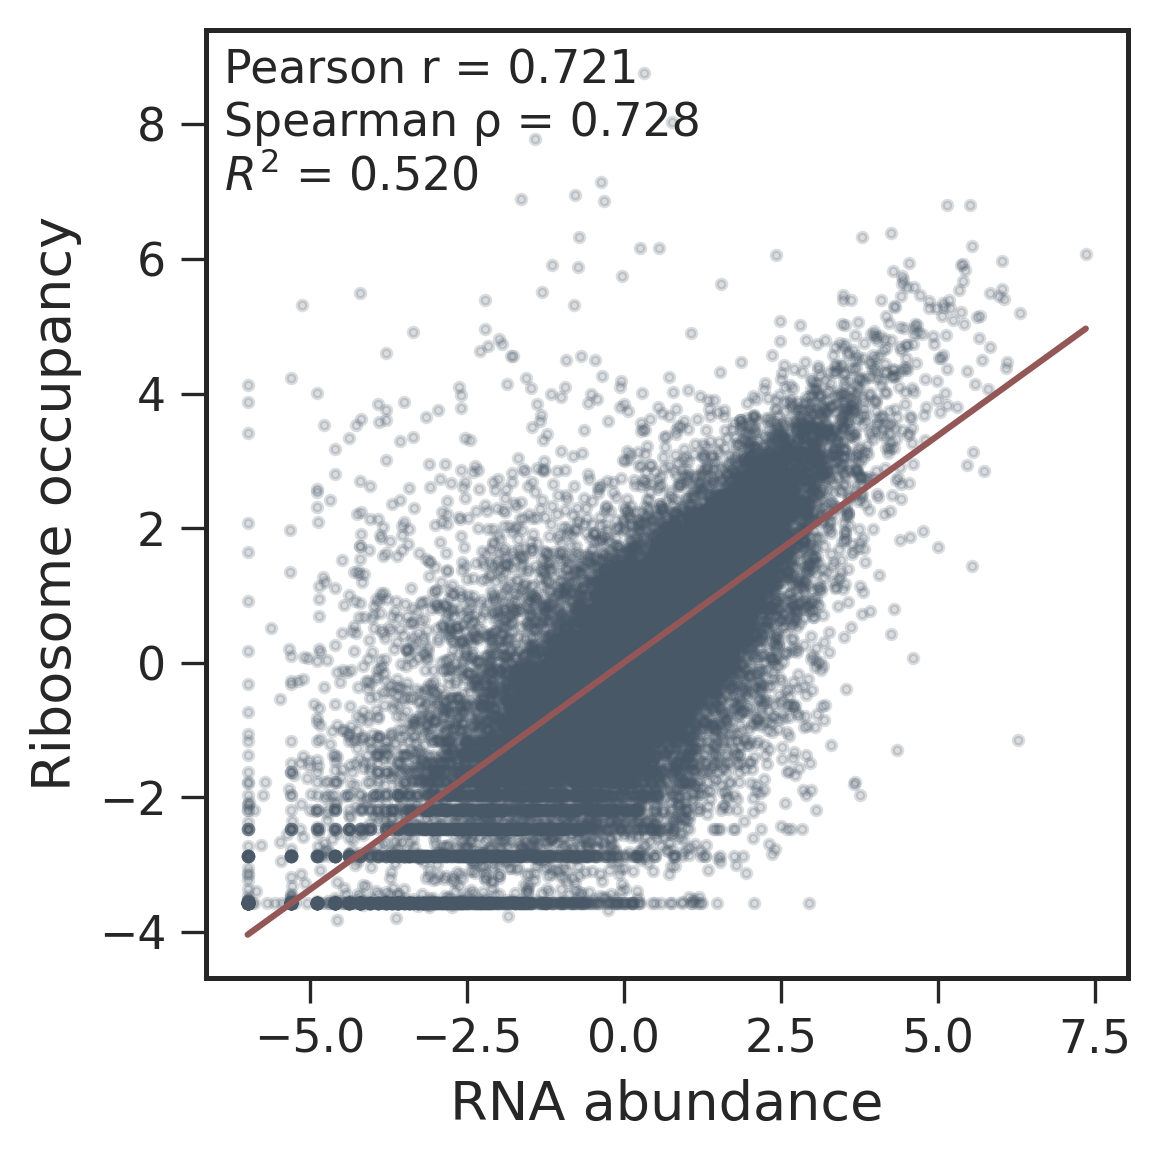

In [29]:
# ============================================
# 05.4 RNA vs Ribo CLR relationship
# ============================================

fig, ax = make_fig(w=4, h=4)

ax.scatter(
    master_te["rna_clr"],
    master_te["ribo_clr"],
    s=5,
    alpha=0.2,
    color="#495867"
)

x = np.linspace(
    master_te["rna_clr"].min(),
    master_te["rna_clr"].max(),
    200,
)

y = (
    te_model.coef_[0] * x
    + te_model.intercept_
)

ax.plot(
    x,
    y,
    linewidth=1.5,
    color="#945757"
)

ax.set_xlabel("RNA abundance")
ax.set_ylabel("Ribosome occupancy")

ax.text(
    0.02,
    0.98,
    (
        f"Pearson r = {pearson_r:.3f}\n"
        f"Spearman ρ = {spearman_r:.3f}\n"
        f"$R^2$ = {r2:.3f}"
    ),
    transform=ax.transAxes,
    ha="left",
    va="top",
)

plt.tight_layout()
plt.show()

In [30]:
# ============================================
# 05.5 Translation-efficiency summary
# ============================================

te_summary = (
    master_te["TE"]
    .describe()
    .rename("Value")
    .to_frame()
)

display(te_summary)

,Value
count,2.230600e+04
mean,-2.038677e-17
std,1.225239e+00
min,-5.553736e+00
25%,-7.189908e-01
50%,1.369184e-02
75%,6.971811e-01
max,8.772957e+00


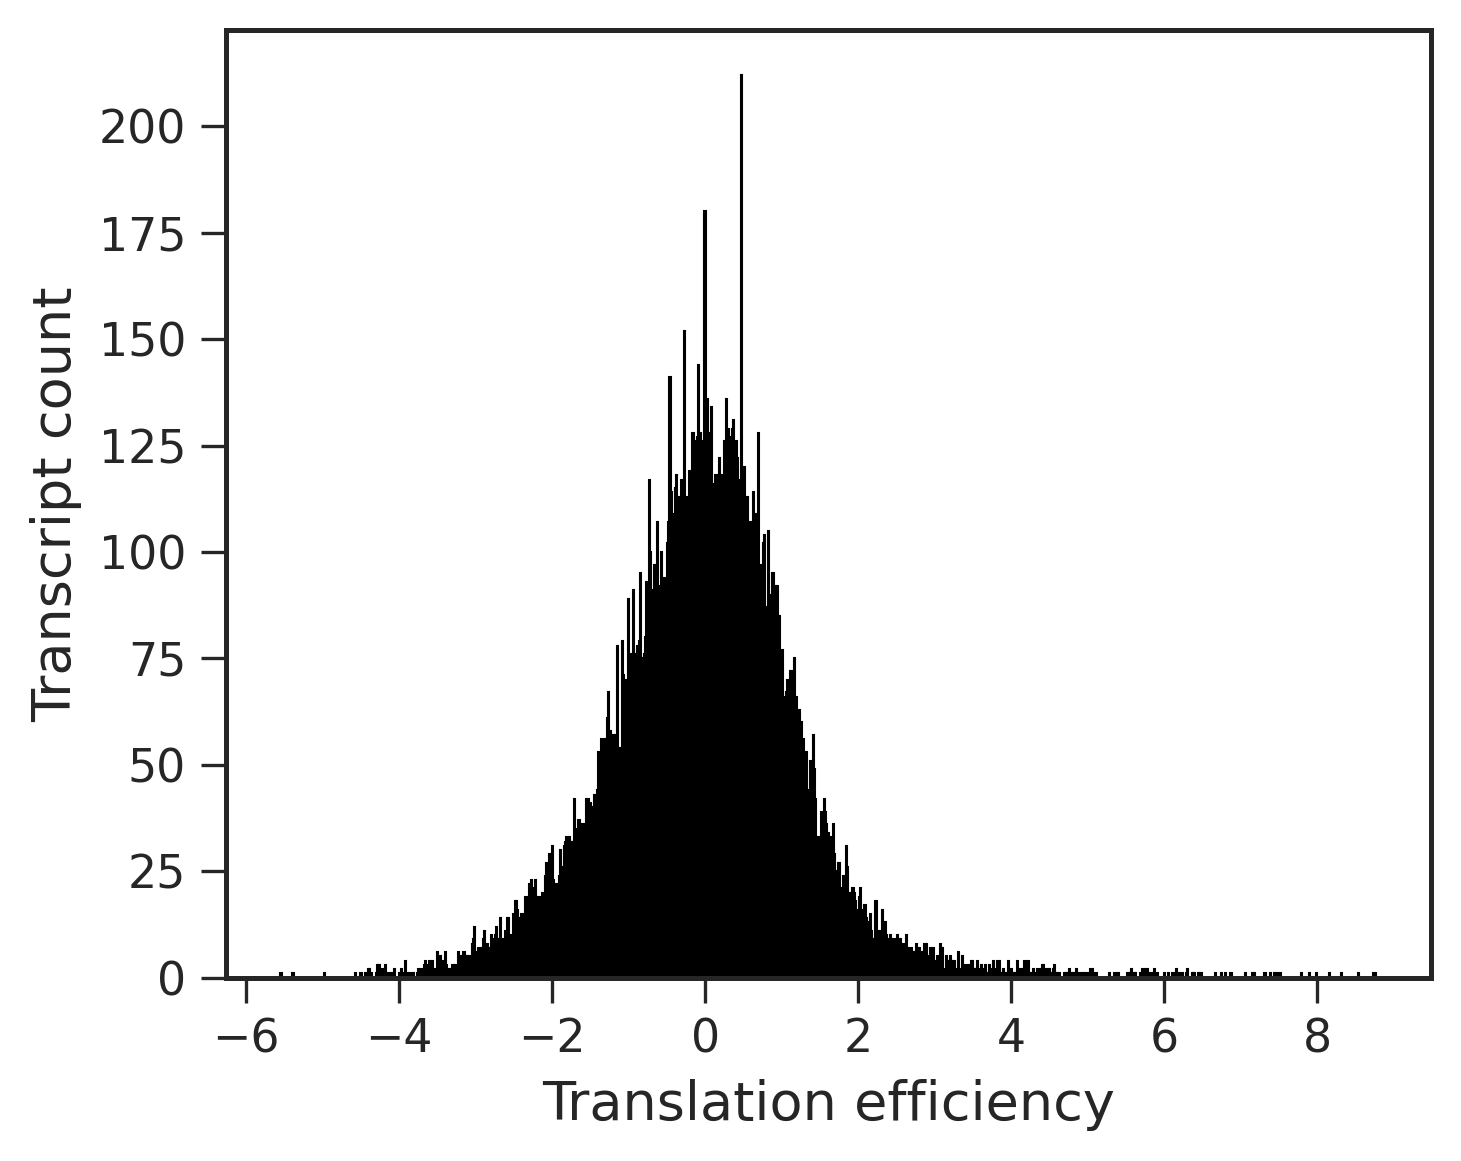

In [31]:
# ============================================
# 05.6 Translation efficiency distribution
# ============================================

fig, ax = make_fig(w=5, h=4)

ax.hist(
    master_te["TE"],
    bins=1000,
    edgecolor="black",
    linewidth=0.5,
)

ax.set_xlabel("Translation efficiency")
ax.set_ylabel("Transcript count")

plt.tight_layout()
plt.show()

In [32]:
# ============================================
# 05.7 Save translation-efficiency results
# ============================================

TE_OUTPUT_FILE = (
    PROCESSED_DIR
    / "translation_efficiency.tsv.gz"
)

master_te.to_csv(
    TE_OUTPUT_FILE,
    sep="\t",
    index=False,
    compression="gzip",
)

print("Saved:")
print(TE_OUTPUT_FILE)

print("\nShape:")
print(master_te.shape)

Saved:
/mnt/d/Ibnu/riboseq/AT/postprocess/arabidopsis_thaliana/processed/translation_efficiency.tsv.gz

Shape:
(22306, 11)


In [33]:
# ============================================
# 06.1 Reference source files
# ============================================

REPO_DIR = Path(
    "/home/ha-ibnu/Code/processing/riboseq"
)

SOURCE_FASTA_GZ = (
    REPO_DIR
    / "refs"
    / "at.fa.gz"
)

SOURCE_GFF3_GZ = (
    REPO_DIR
    / "refs"
    / "at.gff3.gz"
)

reference_sources = {
    "Reference FASTA": SOURCE_FASTA_GZ,
    "Reference GFF3": SOURCE_GFF3_GZ,
}

missing_reference_files = []

for name, path in reference_sources.items():
    if path.exists():
        print(f"OK      {name}: {path}")
    else:
        print(f"MISSING {name}: {path}")
        missing_reference_files.append(path)

if missing_reference_files:
    raise FileNotFoundError(
        "One or more reference source files are missing."
    )

print("\nAll reference source files were found.")

OK      Reference FASTA: /home/ha-ibnu/Code/processing/riboseq/refs/at.fa.gz
OK      Reference GFF3: /home/ha-ibnu/Code/processing/riboseq/refs/at.gff3.gz

All reference source files were found.


In [34]:
# ============================================
# 06.2 Prepare reference FASTA and GFF3
# ============================================

REFERENCE_FASTA = (
    ANNOTATION_DIR
    / "at.fa"
)

REFERENCE_GFF3 = (
    ANNOTATION_DIR
    / "at.gff3"
)


def decompress_gzip(
    source,
    destination,
):
    if destination.exists():
        print(f"Already exists: {destination}")
        return

    with gzip.open(source, "rb") as source_handle:
        with destination.open("wb") as destination_handle:
            destination_handle.write(
                source_handle.read()
            )

    print(f"Created: {destination}")


decompress_gzip(
    SOURCE_FASTA_GZ,
    REFERENCE_FASTA,
)

decompress_gzip(
    SOURCE_GFF3_GZ,
    REFERENCE_GFF3,
)


print("\nPrepared reference files:")
print(REFERENCE_FASTA)
print(REFERENCE_GFF3)

Created: /mnt/d/Ibnu/riboseq/AT/postprocess/arabidopsis_thaliana/annotation/at.fa
Created: /mnt/d/Ibnu/riboseq/AT/postprocess/arabidopsis_thaliana/annotation/at.gff3

Prepared reference files:
/mnt/d/Ibnu/riboseq/AT/postprocess/arabidopsis_thaliana/annotation/at.fa
/mnt/d/Ibnu/riboseq/AT/postprocess/arabidopsis_thaliana/annotation/at.gff3


In [36]:
# ============================================
# 06.3 Generate transcript and CDS FASTA files
# ============================================

TRANSCRIPT_FASTA = (
    ANNOTATION_DIR
    / "transcripts.fa"
)

CDS_FASTA = (
    ANNOTATION_DIR
    / "cds.fa"
)


def run_command(command):
    print("Running:")
    print(" ".join(map(str, command)))

    result = subprocess.run(
        list(map(str, command)),
        check=True,
        capture_output=True,
        text=True,
    )

    if result.stdout.strip():
        print(result.stdout)

    if result.stderr.strip():
        print(result.stderr)


# --------------------------------------------
# Extract spliced transcript sequences
# --------------------------------------------

if TRANSCRIPT_FASTA.exists():
    print(f"Already exists: {TRANSCRIPT_FASTA}")
else:
    run_command([
        "gffread",
        REFERENCE_GFF3,
        "-g",
        REFERENCE_FASTA,
        "-w",
        TRANSCRIPT_FASTA,
    ])


# --------------------------------------------
# Extract CDS sequences
# --------------------------------------------

if CDS_FASTA.exists():
    print(f"Already exists: {CDS_FASTA}")
else:
    run_command([
        "gffread",
        REFERENCE_GFF3,
        "-g",
        REFERENCE_FASTA,
        "-x",
        CDS_FASTA,
    ])


print("\nGenerated FASTA files:")
print(TRANSCRIPT_FASTA)
print(CDS_FASTA)

Running:
gffread /mnt/d/Ibnu/riboseq/AT/postprocess/arabidopsis_thaliana/annotation/at.gff3 -g /mnt/d/Ibnu/riboseq/AT/postprocess/arabidopsis_thaliana/annotation/at.fa -w /mnt/d/Ibnu/riboseq/AT/postprocess/arabidopsis_thaliana/annotation/transcripts.fa
FASTA index file /mnt/d/Ibnu/riboseq/AT/postprocess/arabidopsis_thaliana/annotation/at.fa.fai created.

Running:
gffread /mnt/d/Ibnu/riboseq/AT/postprocess/arabidopsis_thaliana/annotation/at.gff3 -g /mnt/d/Ibnu/riboseq/AT/postprocess/arabidopsis_thaliana/annotation/at.fa -x /mnt/d/Ibnu/riboseq/AT/postprocess/arabidopsis_thaliana/annotation/cds.fa


Generated FASTA files:
/mnt/d/Ibnu/riboseq/AT/postprocess/arabidopsis_thaliana/annotation/transcripts.fa
/mnt/d/Ibnu/riboseq/AT/postprocess/arabidopsis_thaliana/annotation/cds.fa


In [37]:
# ============================================
# 06.4 Validate generated FASTA files
# ============================================

def count_fasta_records(fasta_file):
    count = 0

    with fasta_file.open() as handle:
        for line in handle:
            if line.startswith(">"):
                count += 1

    return count


# --------------------------------------------
# File existence and size
# --------------------------------------------

for path in [
    TRANSCRIPT_FASTA,
    CDS_FASTA,
]:
    if not path.exists():
        raise FileNotFoundError(
            f"Missing FASTA file: {path}"
        )

    print(
        f"{path.name}: "
        f"{path.stat().st_size / 1024**2:.2f} MB"
    )


# --------------------------------------------
# Record counts
# --------------------------------------------

n_transcripts = count_fasta_records(
    TRANSCRIPT_FASTA
)

n_cds = count_fasta_records(
    CDS_FASTA
)

print("\nFASTA record counts")
print(f"Transcripts: {n_transcripts:,}")
print(f"CDS        : {n_cds:,}")


# --------------------------------------------
# Inspect first records
# --------------------------------------------

print("\nTranscript FASTA preview:")

with TRANSCRIPT_FASTA.open() as handle:
    for _ in range(4):
        print(handle.readline().rstrip())


print("\nCDS FASTA preview:")

with CDS_FASTA.open() as handle:
    for _ in range(4):
        print(handle.readline().rstrip())

transcripts.fa: 97.49 MB
cds.fa: 61.28 MB

FASTA record counts
Transcripts: 59,478
CDS        : 48,359

Transcript FASTA preview:
>AT1G01010.1 CDS=130-1419
AAATTATTAGATATACCAAACCAGAGAAAACAAATACATAATCGGAGAAATACAGATTACAGAGAGCGAG
AGAGATCGACGGCGAAGCTCTTTACCCGGAAACCATTGAAATCGGACGGTTTAGTGAAAATGGAGGATCA
AGTTGGGTTTGGGTTCCGTCCGAACGACGAGGAGCTCGTTGGTCACTATCTCCGTAACAAAATCGAAGGA

CDS FASTA preview:
>AT1G01010.1
ATGGAGGATCAAGTTGGGTTTGGGTTCCGTCCGAACGACGAGGAGCTCGTTGGTCACTATCTCCGTAACA
AAATCGAAGGAAACACTAGCCGCGACGTTGAAGTAGCCATCAGCGAGGTCAACATCTGTAGCTACGATCC
TTGGAACTTGCGCTTCCAGTCAAAGTACAAATCGAGAGATGCTATGTGGTACTTCTTCTCTCGTAGAGAA


In [38]:
# ============================================
# 06.5 Extract transcript-region sequences
# ============================================

records = []

current_transcript = None
current_cds_start = None
current_cds_end = None
sequence_parts = []


def build_transcript_record(
    transcript_id,
    cds_start,
    cds_end,
    sequence_parts,
):
    if transcript_id is None:
        return None

    sequence = "".join(sequence_parts).upper()

    if cds_start is None or cds_end is None:
        utr5_seq = None
        cds_seq = None
        utr3_seq = None
    else:
        # CDS coordinates in the FASTA header are
        # 1-based and inclusive.
        utr5_seq = sequence[:cds_start - 1]
        cds_seq = sequence[cds_start - 1:cds_end]
        utr3_seq = sequence[cds_end:]

    return {
        "transcript_id": transcript_id,
        "mrna_seq": sequence,
        "utr5_seq": utr5_seq,
        "cds_seq": cds_seq,
        "utr3_seq": utr3_seq,
        "mrna_length": len(sequence),
        "utr5_length": (
            len(utr5_seq)
            if utr5_seq is not None
            else np.nan
        ),
        "cds_length": (
            len(cds_seq)
            if cds_seq is not None
            else np.nan
        ),
        "utr3_length": (
            len(utr3_seq)
            if utr3_seq is not None
            else np.nan
        ),
    }


with TRANSCRIPT_FASTA.open() as handle:
    for raw_line in handle:
        line = raw_line.strip()

        if line.startswith(">"):
            previous_record = build_transcript_record(
                current_transcript,
                current_cds_start,
                current_cds_end,
                sequence_parts,
            )

            if previous_record is not None:
                records.append(previous_record)

            header = line[1:]
            current_transcript = header.split()[0]

            cds_match = re.search(
                r"CDS=(\d+)-(\d+)",
                header,
            )

            if cds_match:
                current_cds_start = int(
                    cds_match.group(1)
                )
                current_cds_end = int(
                    cds_match.group(2)
                )
            else:
                current_cds_start = None
                current_cds_end = None

            sequence_parts = []

        else:
            sequence_parts.append(line)


final_record = build_transcript_record(
    current_transcript,
    current_cds_start,
    current_cds_end,
    sequence_parts,
)

if final_record is not None:
    records.append(final_record)


transcript_regions = pd.DataFrame(records)


print(
    "Extracted transcript records:",
    f"{len(transcript_regions):,}",
)

display(
    transcript_regions[[
        "transcript_id",
        "mrna_length",
        "utr5_length",
        "cds_length",
        "utr3_length",
    ]].head()
)

Extracted transcript records: 59,478


,transcript_id,mrna_length,utr5_length,cds_length,utr3_length
0,AT1G01010.1,1688,129.0,1290.0,269.0
1,AT1G01020.2,1087,71.0,576.0,440.0
2,AT1G01020.6,944,189.0,315.0,440.0
3,AT1G01020.1,1329,464.0,738.0,127.0
4,AT1G01020.3,1420,582.0,711.0,127.0


In [39]:
# ============================================
# 06.6 Validate transcript-region extraction
# ============================================

# --------------------------------------------
# Duplicate transcript IDs
# --------------------------------------------

duplicate_transcripts = (
    transcript_regions["transcript_id"]
    .duplicated()
    .sum()
)

print(
    "Duplicate transcript IDs:",
    duplicate_transcripts,
)


# --------------------------------------------
# Missing sequence regions
# --------------------------------------------

region_missing = (
    transcript_regions[[
        "mrna_seq",
        "utr5_seq",
        "cds_seq",
        "utr3_seq",
    ]]
    .isna()
    .sum()
    .rename("Missing")
    .to_frame()
)

display(region_missing)


# --------------------------------------------
# Check region-length consistency
# --------------------------------------------

coding_regions = transcript_regions.loc[
    transcript_regions["cds_seq"].notna()
].copy()

coding_regions["combined_region_length"] = (
    coding_regions["utr5_length"]
    + coding_regions["cds_length"]
    + coding_regions["utr3_length"]
)

coding_regions["length_consistent"] = (
    coding_regions["combined_region_length"]
    == coding_regions["mrna_length"]
)

coding_regions["cds_divisible_by_3"] = (
    coding_regions["cds_length"] % 3 == 0
)


validation_summary = pd.DataFrame({
    "Metric": [
        "Total transcript records",
        "Protein-coding transcript records",
        "Consistent region lengths",
        "Inconsistent region lengths",
        "CDS lengths divisible by 3",
        "CDS lengths not divisible by 3",
    ],
    "Value": [
        len(transcript_regions),
        len(coding_regions),
        coding_regions["length_consistent"].sum(),
        (~coding_regions["length_consistent"]).sum(),
        coding_regions["cds_divisible_by_3"].sum(),
        (~coding_regions["cds_divisible_by_3"]).sum(),
    ],
})

display(validation_summary)

Duplicate transcript IDs: 0


,Missing
mrna_seq,0
utr5_seq,11119
cds_seq,11119
utr3_seq,11119


,Metric,Value
0,Total transcript records,59478
1,Protein-coding transcript records,48359
2,Consistent region lengths,48359
3,Inconsistent region lengths,0
4,CDS lengths divisible by 3,48320
5,CDS lengths not divisible by 3,39


In [43]:
# ============================================
# 06.7 Merge transcript sequences with TE table
# ============================================

master_sequence = master_te.merge(
    transcript_regions,
    on="transcript_id",
    how="left",
)

print(
    "Rows before merge:",
    f"{len(master_te):,}",
)

print(
    "Rows after merge :",
    f"{len(master_sequence):,}",
)

print(
    "Transcripts with mRNA sequence:",
    f"{master_sequence['mrna_seq'].notna().sum():,}",
)

print(
    "Transcripts with CDS sequence:",
    f"{master_sequence['cds_seq'].notna().sum():,}",
)

print(
    "Transcripts missing mRNA sequence:",
    f"{master_sequence['mrna_seq'].isna().sum():,}",
)

display(
    master_sequence[
        [
            "transcript_id",
            "gene_id",
            "ribo_read_count",
            "rna_read_count",
            "ribo_tpm",
            "rna_tpm",
            "TE",
            "utr5_seq",
            "cds_seq",
            "utr3_seq",
            "mrna_seq",
        ]
    ]
    .rename(
        columns={
            "transcript_id": "trans_id",
            "ribo_read_count": "Ribo_count",
            "rna_read_count": "RNA_count",
            "ribo_tpm": "Ribo_TPM",
            "rna_tpm": "RNA_TPM",
            "utr5_seq": "5'UTR",
            "cds_seq": "CDS",
            "utr3_seq": "3'UTR",
            "mrna_seq": "mRNA",
        }
    )
    .head()
)

Rows before merge: 22,306
Rows after merge : 22,306
Transcripts with mRNA sequence: 22,306
Transcripts with CDS sequence: 21,696
Transcripts missing mRNA sequence: 0


,trans_id,gene_id,Ribo_count,RNA_count,Ribo_TPM,RNA_TPM,TE,5'UTR,CDS,3'UTR,mRNA
0,AT1G01010.1,AT1G01010,24.00,157.000,0.107730,2.876792,0.238028,AAATTATTAGATATACCAAACCAGAGAAAACAAATACATAATCGGA...,ATGGAGGATCAAGTTGGGTTTGGGTTCCGTCCGAACGACGAGGAGC...,GAGGTCAAATCGGATTCTTGCTCAAAATTTGTATTTCTTAGAATGT...,AAATTATTAGATATACCAAACCAGAGAAAACAAATACATAATCGGA...
1,AT1G01020.2,AT1G01020,14.00,211.134,0.107966,6.646622,-0.500903,AGACCCGGACTCTAATTGCTCCGTATTCTTCTTCTCTTGAGAGAGA...,ATGGCGGCGAGTGAACACAGATGCGTGGGATGTGGTTTTAGGGTAA...,ATCATGCACTAAAGTTTCTTGTATTGATTAAACATGGTGTTATGTC...,AGACCCGGACTCTAATTGCTCCGTATTCTTCTTCTCTTGAGAGAGA...
2,AT1G01030.2,AT1G01030,7.00,19.582,0.028489,0.325320,0.410760,ATATCATTCATGGGCCCCTACGCATTACTCGGTACCAATCTCGCTC...,ATGGATCTATCCCTGGCTCCGACAACAACAACAAGTTCCGACCAAG...,GAAGTTTCATCATCTTCTTGTTTTGAATCTCTCTTTATATTGTTTC...,ATATCATTCATGGGCCCCTACGCATTACTCGGTACCAATCTCGCTC...
3,AT1G01040.1,AT1G01040,48.00,2345.008,0.051416,10.253755,-0.893593,GTGGAAAACAGACCAGAAGAGAGAGGAAGACGAAGAGAGAAACAGA...,ATGGTAATGGAGGATGAGCCTAGAGAAGCCACAATAAAGCCTTCTT...,TTCTTTTACTCTCTTCAACGAGATGTAGTCATTACATTTTAAACCT...,GTGGAAAACAGACCAGAAGAGAGAGGAAGACGAAGAGAGAAACAGA...
4,AT1G01050.1,AT1G01050,197.02,2517.218,1.709312,89.148807,0.470685,TCCGTATATCTCGGTGGTGACTCATATATACATTTTACAATCACTT...,ATGAGTGAAGAAACTAAAGATAACCAGAGGCTGCAGCGACCAGCTC...,AGCTTCTCCTCAGAAGATTTCTGCAGCATCTATGTTTCTGTTACTT...,TCCGTATATCTCGGTGGTGACTCATATATACATTTTACAATCACTT...


In [44]:
# ============================================
# 06.8 Save final transcript-level table
# ============================================

AT_shoot_14dag = (
    master_sequence[
        [
            "transcript_id",
            "gene_id",
            "ribo_read_count",
            "rna_read_count",
            "ribo_tpm",
            "rna_tpm",
            "TE",
            "utr5_seq",
            "cds_seq",
            "utr3_seq",
            "mrna_seq",
        ]
    ]
    .rename(
        columns={
            "transcript_id": "trans_id",
            "ribo_read_count": "Ribo_count",
            "rna_read_count": "RNA_count",
            "ribo_tpm": "Ribo_TPM",
            "rna_tpm": "RNA_TPM",
            "utr5_seq": "5'UTR",
            "cds_seq": "CDS",
            "utr3_seq": "3'UTR",
            "mrna_seq": "mRNA",
        }
    )
    .copy()
)

AT_OUTPUT_FILE = (
    PROCESSED_DIR
    / "AT_shoot_14dag.tsv.gz"
)

AT_shoot_14dag.to_csv(
    AT_OUTPUT_FILE,
    sep="\t",
    index=False,
    compression="gzip",
)

print("Saved:")
print(AT_OUTPUT_FILE)

print("\nShape:")
print(AT_shoot_14dag.shape)

display(
    AT_shoot_14dag.head()
)

Saved:
/mnt/d/Ibnu/riboseq/AT/postprocess/arabidopsis_thaliana/processed/AT_shoot_14dag.tsv.gz

Shape:
(22306, 11)


,trans_id,gene_id,Ribo_count,RNA_count,Ribo_TPM,RNA_TPM,TE,5'UTR,CDS,3'UTR,mRNA
0,AT1G01010.1,AT1G01010,24.00,157.000,0.107730,2.876792,0.238028,AAATTATTAGATATACCAAACCAGAGAAAACAAATACATAATCGGA...,ATGGAGGATCAAGTTGGGTTTGGGTTCCGTCCGAACGACGAGGAGC...,GAGGTCAAATCGGATTCTTGCTCAAAATTTGTATTTCTTAGAATGT...,AAATTATTAGATATACCAAACCAGAGAAAACAAATACATAATCGGA...
1,AT1G01020.2,AT1G01020,14.00,211.134,0.107966,6.646622,-0.500903,AGACCCGGACTCTAATTGCTCCGTATTCTTCTTCTCTTGAGAGAGA...,ATGGCGGCGAGTGAACACAGATGCGTGGGATGTGGTTTTAGGGTAA...,ATCATGCACTAAAGTTTCTTGTATTGATTAAACATGGTGTTATGTC...,AGACCCGGACTCTAATTGCTCCGTATTCTTCTTCTCTTGAGAGAGA...
2,AT1G01030.2,AT1G01030,7.00,19.582,0.028489,0.325320,0.410760,ATATCATTCATGGGCCCCTACGCATTACTCGGTACCAATCTCGCTC...,ATGGATCTATCCCTGGCTCCGACAACAACAACAAGTTCCGACCAAG...,GAAGTTTCATCATCTTCTTGTTTTGAATCTCTCTTTATATTGTTTC...,ATATCATTCATGGGCCCCTACGCATTACTCGGTACCAATCTCGCTC...
3,AT1G01040.1,AT1G01040,48.00,2345.008,0.051416,10.253755,-0.893593,GTGGAAAACAGACCAGAAGAGAGAGGAAGACGAAGAGAGAAACAGA...,ATGGTAATGGAGGATGAGCCTAGAGAAGCCACAATAAAGCCTTCTT...,TTCTTTTACTCTCTTCAACGAGATGTAGTCATTACATTTTAAACCT...,GTGGAAAACAGACCAGAAGAGAGAGGAAGACGAAGAGAGAAACAGA...
4,AT1G01050.1,AT1G01050,197.02,2517.218,1.709312,89.148807,0.470685,TCCGTATATCTCGGTGGTGACTCATATATACATTTTACAATCACTT...,ATGAGTGAAGAAACTAAAGATAACCAGAGGCTGCAGCGACCAGCTC...,AGCTTCTCCTCAGAAGATTTCTGCAGCATCTATGTTTCTGTTACTT...,TCCGTATATCTCGGTGGTGACTCATATATACATTTTACAATCACTT...


In [45]:
# ============================================
# 07.1 P-site annotation overview
# ============================================

psite_overview = pd.DataFrame({
    "Metric": [
        "Total P-sites",
        "Unique transcripts",
        "Minimum RPF length",
        "Maximum RPF length",
        "Number of observed RPF lengths",
    ],
    "Value": [
        len(psite),
        psite["transcript"].nunique(),
        psite["length"].min(),
        psite["length"].max(),
        psite["length"].nunique(),
    ],
})

display(psite_overview)


print("P-site table columns:")

for column in psite.columns:
    print(column)


print("\nP-site region labels:")

display(
    psite["psite_region"]
    .value_counts()
    .rename_axis("Region")
    .reset_index(name="P_sites")
)


print("\nRPF lengths:")

display(
    psite["length"]
    .value_counts()
    .sort_index()
    .rename_axis("Length")
    .reset_index(name="P_sites")
)

,Metric,Value
0,Total P-sites,20461066
1,Unique transcripts,41476
2,Minimum RPF length,20
3,Maximum RPF length,46
4,Number of observed RPF lengths,27


P-site table columns:
transcript
end5
psite
end3
length
cds_start
cds_stop
psite_from_start
psite_from_stop
psite_region
p_site_codon
sample

P-site region labels:


,Region,P_sites
0,cds,7670458
1,5utr,192951
2,3utr,156411



RPF lengths:


,Length,P_sites
0,20,21578
1,21,47867
2,22,92565
3,23,157230
4,24,225951
5,25,483863
6,26,970774
7,27,1586552
8,28,4311881
9,29,6584339


,Region,P_sites,Percentage,Region_label
0,5utr,192951,2.405927,5′UTR
1,cds,7670458,95.643768,CDS
2,3utr,156411,1.950306,3′UTR


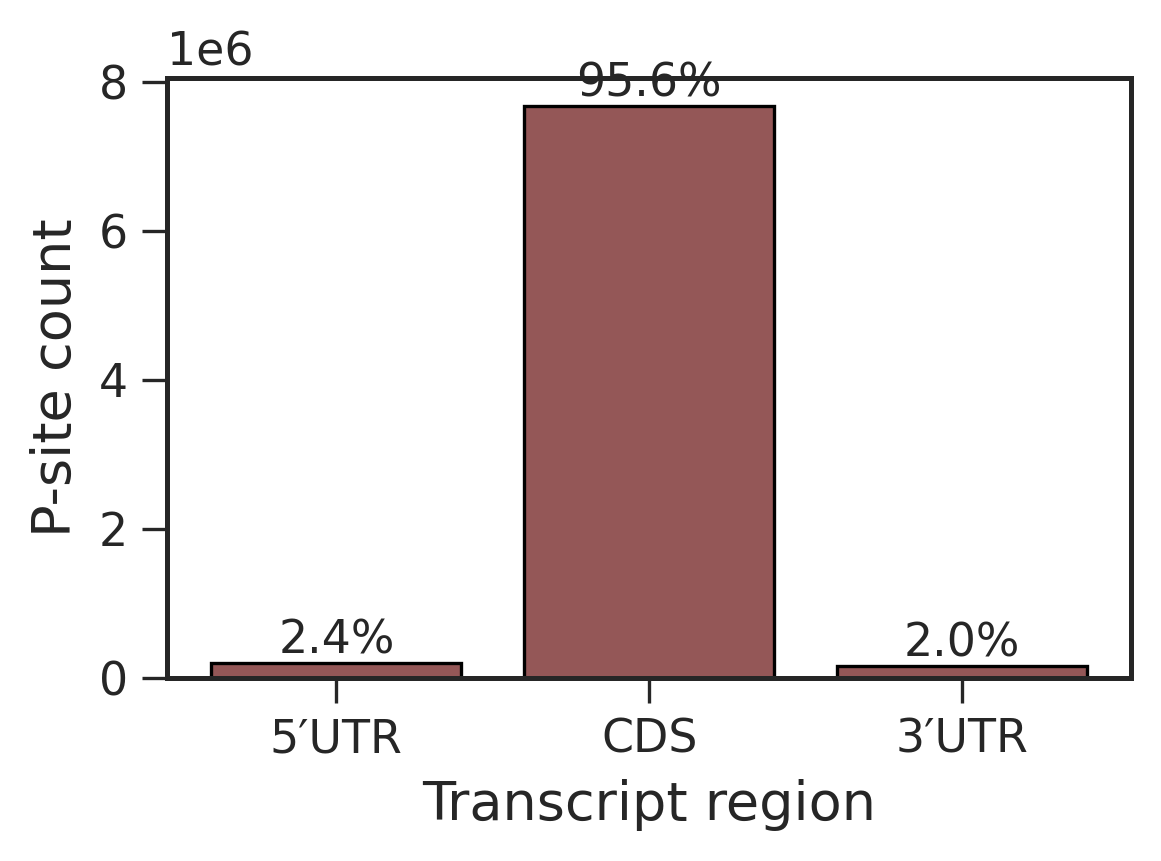

In [52]:
# ============================================
# 07.2 P-site distribution across transcript regions
# ============================================

region_counts = (
    psite["psite_region"]
    .str.lower()
    .value_counts()
    .reindex(
        [
            "5utr",
            "cds",
            "3utr",
        ],
        fill_value=0,
    )
    .rename_axis("Region")
    .reset_index(name="P_sites")
)

region_counts["Percentage"] = (
    region_counts["P_sites"]
    / region_counts["P_sites"].sum()
    * 100
)

region_labels = {
    "5utr": "5′UTR",
    "cds": "CDS",
    "3utr": "3′UTR",
}

region_counts["Region_label"] = (
    region_counts["Region"]
    .map(region_labels)
)

display(region_counts)

fig, ax = make_fig(
    w=4,
    h=3,
)

bars = ax.bar(
    region_counts["Region_label"],
    region_counts["P_sites"],
    color="#945757",
    edgecolor="black",
    linewidth=0.8,
)

for bar, percentage in zip(
    bars,
    region_counts["Percentage"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage:.1f}%",
        ha="center",
        va="bottom",
    )

ax.set_xlabel("Transcript region")
ax.set_ylabel("P-site count")

plt.tight_layout()
plt.show()

,Length,P_sites,Percentage
0,20,21578,0.105459
1,21,47867,0.233942
2,22,92565,0.452396
3,23,157230,0.768435
4,24,225951,1.104297
5,25,483863,2.364799
6,26,970774,4.744494
7,27,1586552,7.754005
8,28,4311881,21.073589
9,29,6584339,32.179843


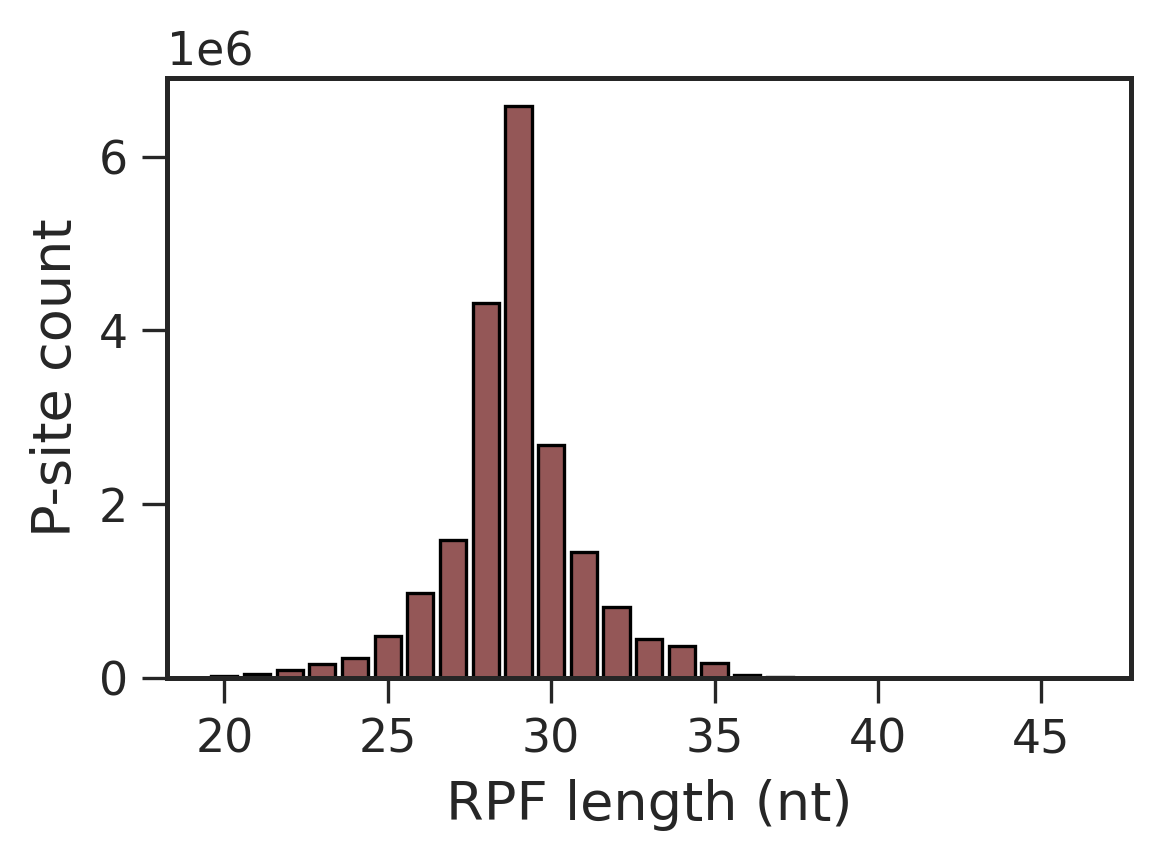

In [51]:
# ============================================
# 07.3 RPF length distribution
# ============================================

length_counts = (
    psite["length"]
    .value_counts()
    .sort_index()
    .rename_axis("Length")
    .reset_index(name="P_sites")
)

length_counts["Percentage"] = (
    length_counts["P_sites"]
    / length_counts["P_sites"].sum()
    * 100
)

display(length_counts)

fig, ax = make_fig(
    w=4,
    h=3,
)

ax.bar(
    length_counts["Length"],
    length_counts["P_sites"],
    color="#945757",
    edgecolor="black",
    linewidth=0.8,
)

ax.set_xlabel("RPF length (nt)")
ax.set_ylabel("P-site count")

plt.tight_layout()
plt.show()

frame,0,1,2
length,,,
20,1920,682,229
21,5940,859,335
22,8961,3067,526
23,10757,4089,1162
24,25114,4879,2763
25,48011,12590,5138
26,79870,30235,10339
27,225084,41200,56605
28,2065704,124499,74644


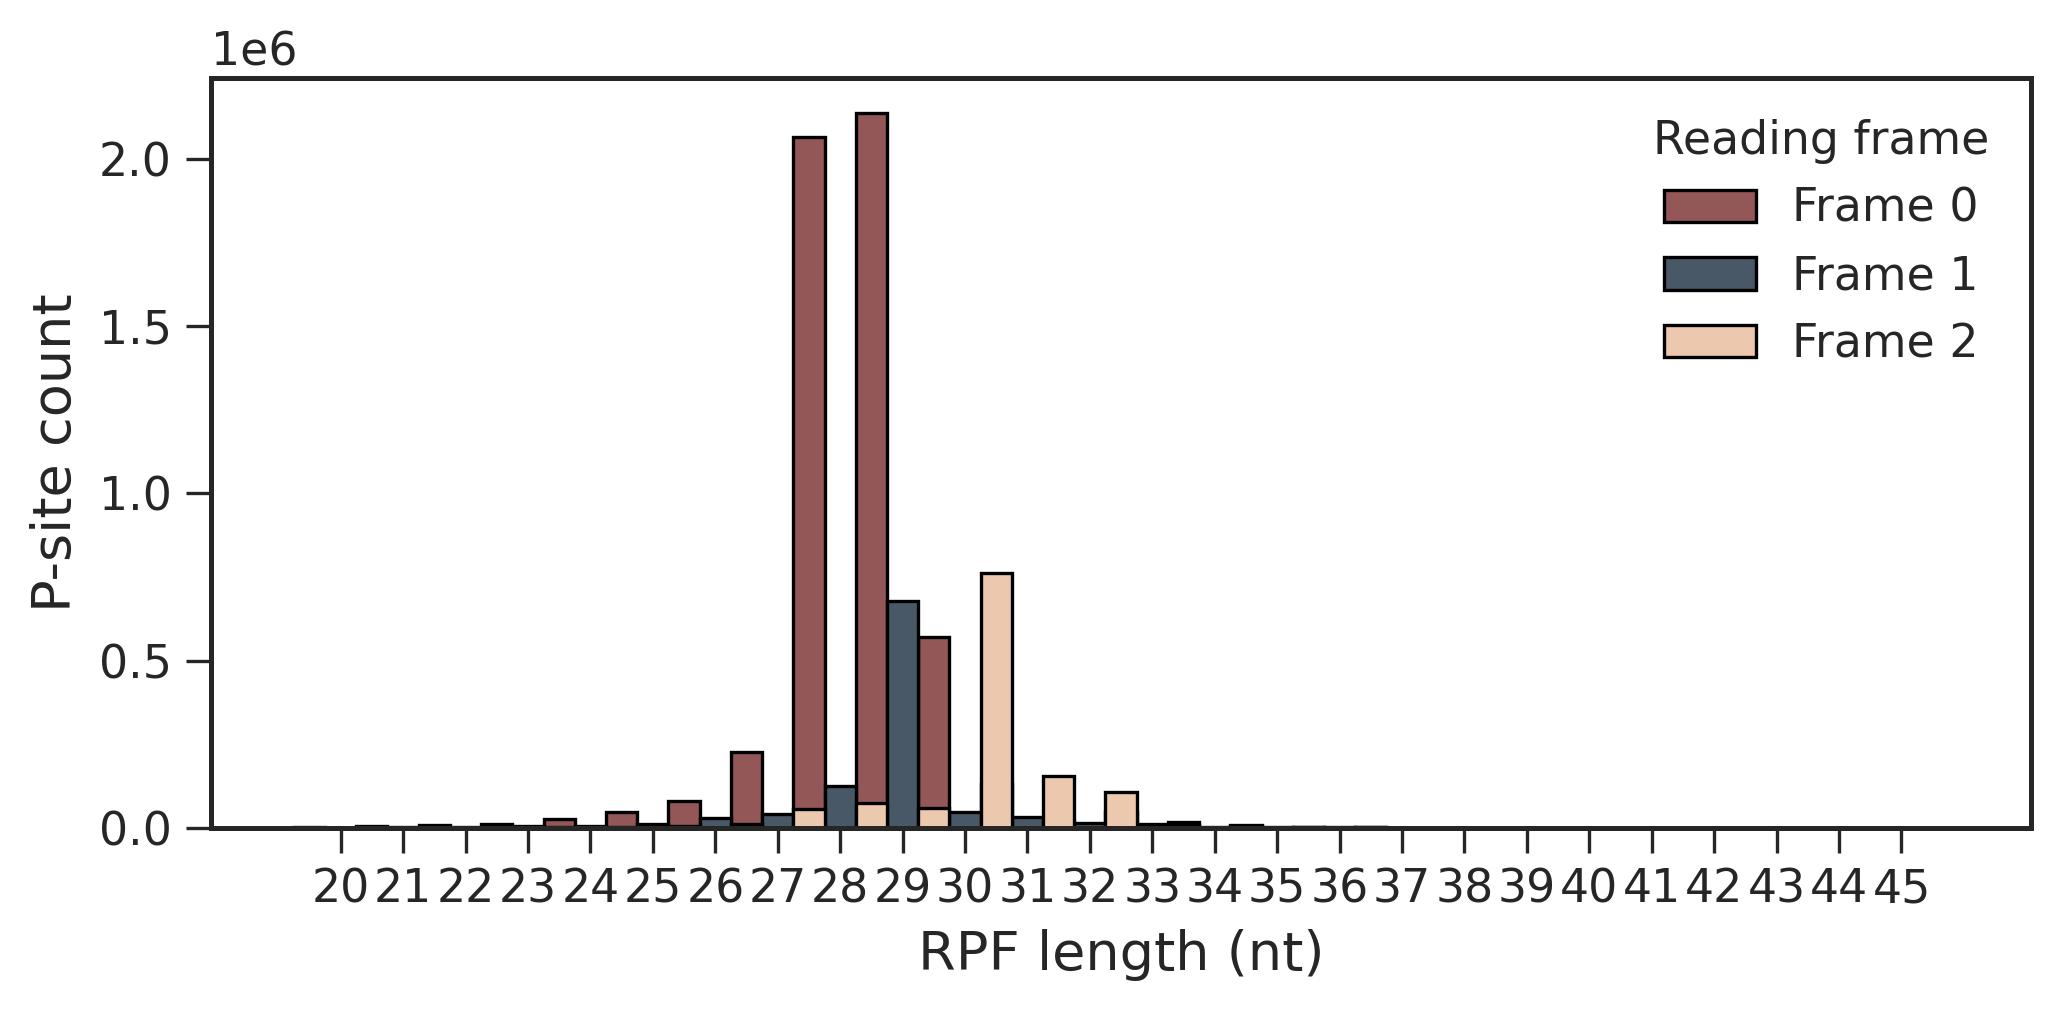

In [70]:
# ============================================
# 07.4 RPF length by reading frame
# ============================================

cds_psite = psite.loc[
    psite["psite_region"].str.lower() == "cds"
].copy()

cds_psite["frame"] = (
    cds_psite["psite_from_start"] % 3
)

length_frame = (
    cds_psite
    .groupby(["length", "frame"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[0, 1, 2], fill_value=0)
)

display(length_frame)

fig, ax = make_fig(
    w=7,
    h=3.5,
)

lengths = length_frame.index.to_numpy()

width = 0.5

ax.bar(
    lengths - width,
    length_frame[0],
    width=width,
    color="#945757",
    edgecolor="black",
    linewidth=0.8,
    label="Frame 0",
)

ax.bar(
    lengths,
    length_frame[1],
    width=width,
    color="#495867",
    edgecolor="black",
    linewidth=0.8,
    label="Frame 1",
)

ax.bar(
    lengths + width,
    length_frame[2],
    width=width,
    color="#ecc8af",
    edgecolor="black",
    linewidth=0.8,
    label="Frame 2",
)

ax.set_xticks(lengths)

ax.set_xlabel("RPF length (nt)")
ax.set_ylabel("P-site count")

ax.legend(
    title="Reading frame",
    frameon=False,
)

plt.tight_layout()
plt.show()

,Frame,P_sites,Percentage
0,Frame 0,5405259,70.468530
1,Frame 1,1013202,13.209146
2,Frame 2,1251997,16.322324


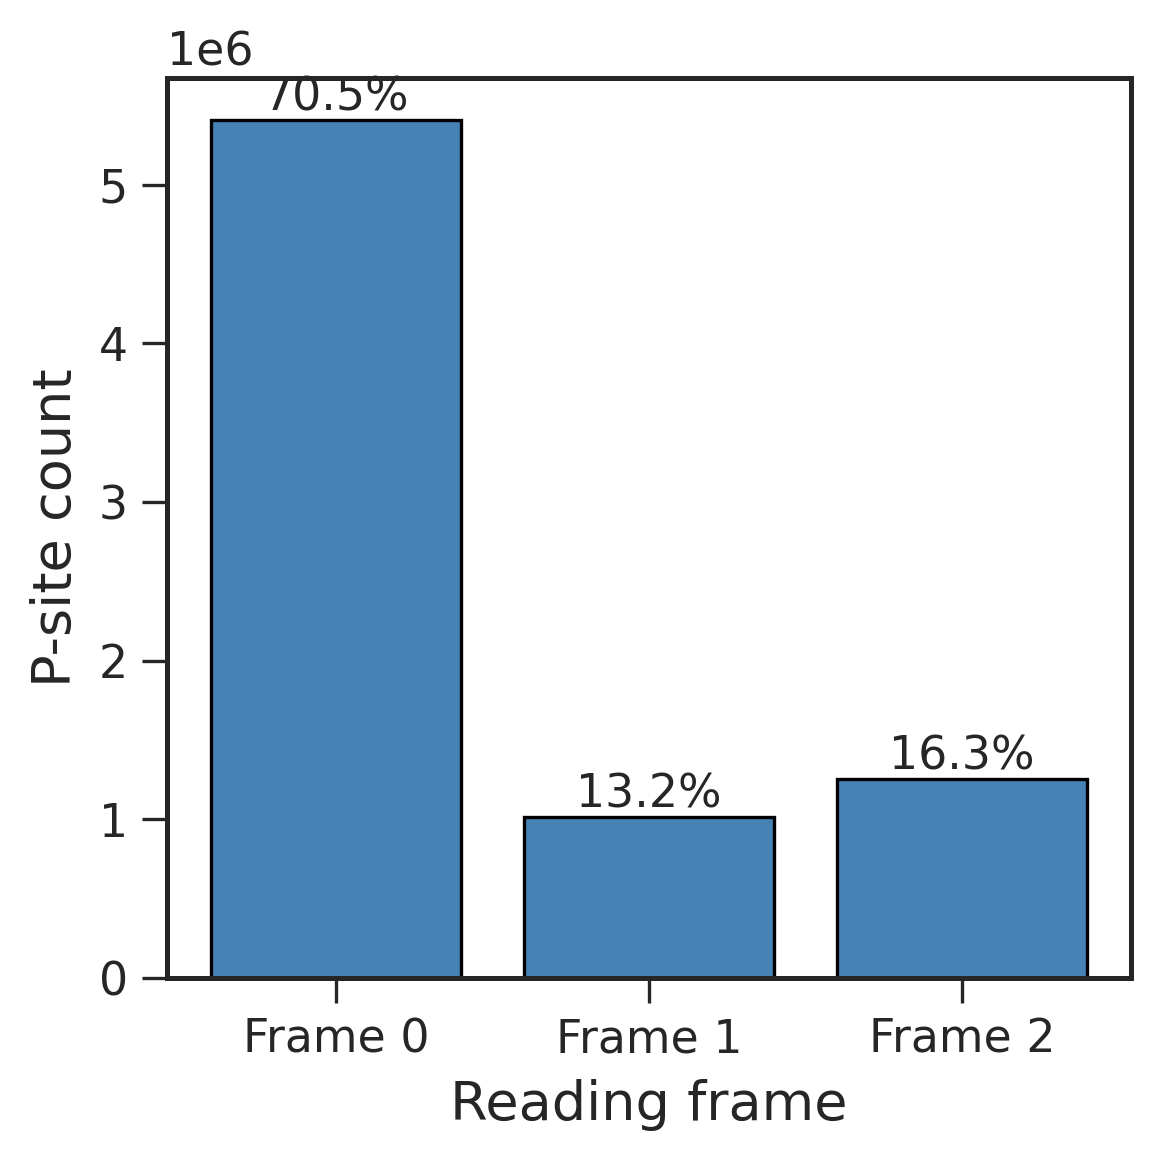

In [60]:
# ============================================
# 07.5 Reading-frame distribution
# ============================================

cds_psite = psite.loc[
    psite["psite_region"].str.lower() == "cds"
].copy()

cds_psite["frame"] = (
    cds_psite["psite_from_start"] % 3
)

frame_counts = (
    cds_psite["frame"]
    .value_counts()
    .sort_index()
    .rename_axis("Frame")
    .reset_index(name="P_sites")
)

frame_counts["Percentage"] = (
    frame_counts["P_sites"]
    / frame_counts["P_sites"].sum()
    * 100
)

frame_counts["Frame"] = (
    "Frame "
    + frame_counts["Frame"].astype(str)
)

display(frame_counts)

fig, ax = make_fig(
    w=4,
    h=4,
)

bars = ax.bar(
    frame_counts["Frame"],
    frame_counts["P_sites"],
    color="steelblue",
    edgecolor="black",
    linewidth=0.8,
)

for bar, pct in zip(
    bars,
    frame_counts["Percentage"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
    )

ax.set_xlabel("Reading frame")
ax.set_ylabel("P-site count")

plt.tight_layout()
plt.show()

,Position,P_sites
0,-40,870
1,-39,905
2,-38,1087
3,-37,986
4,-36,1199


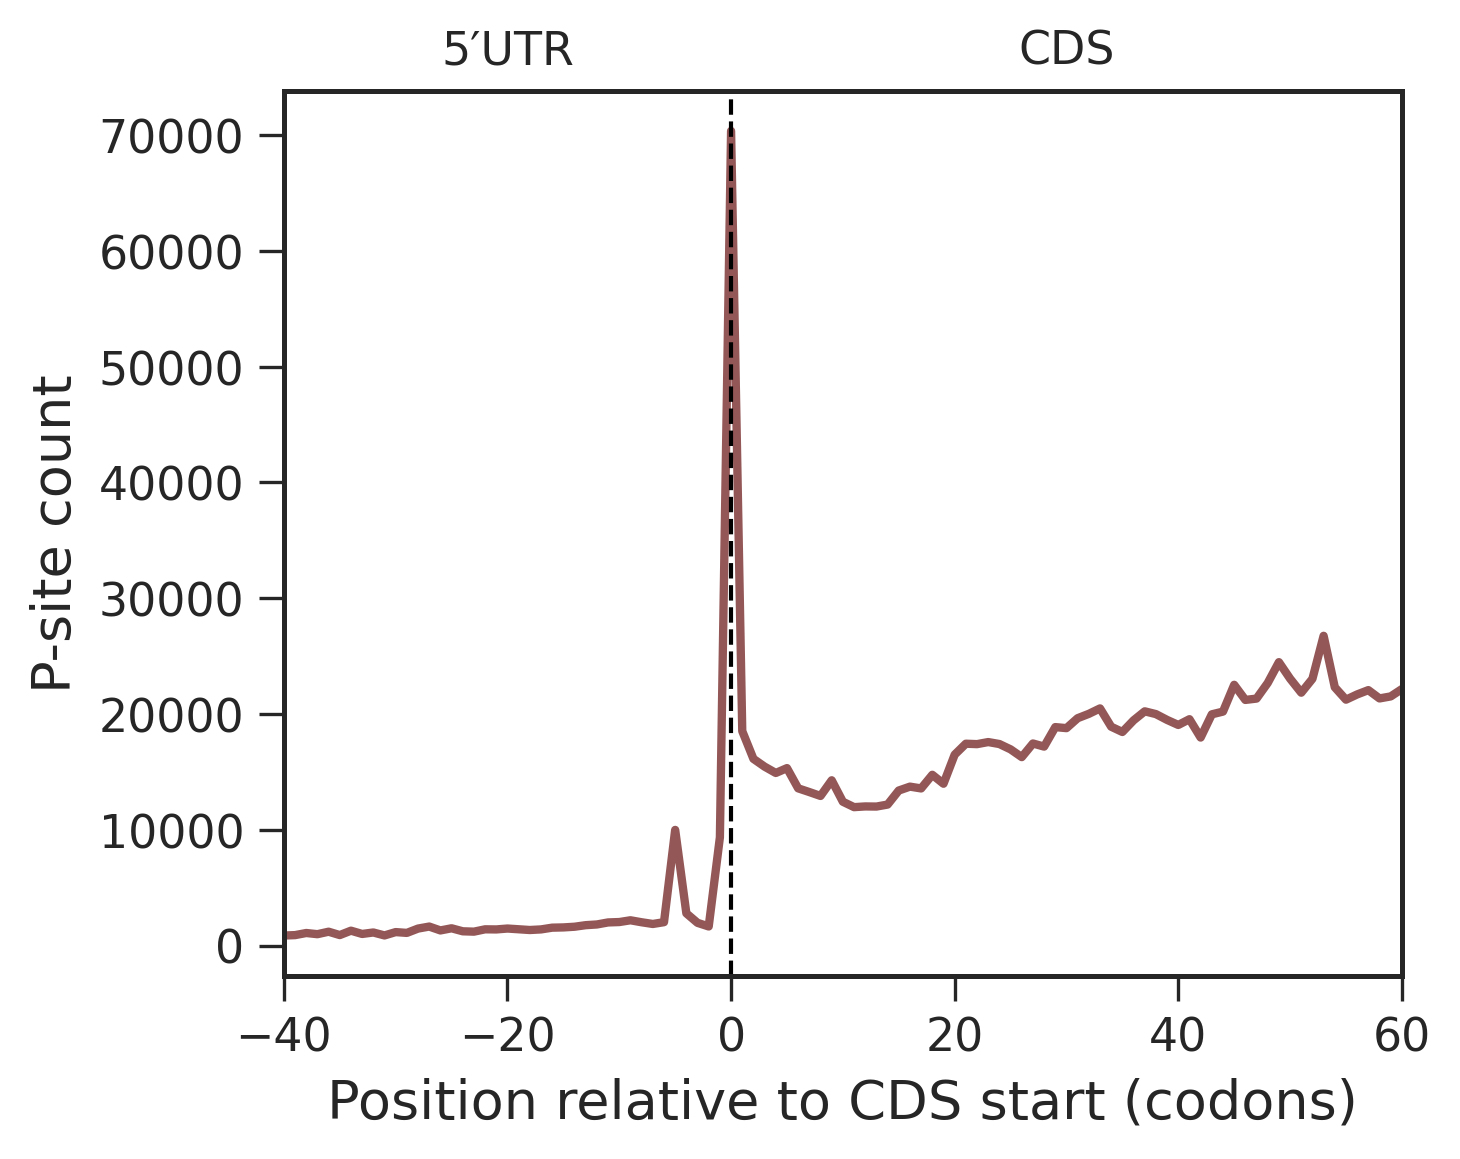

In [66]:
# ============================================
# 07.6 Start-codon metagene
# ============================================

start_metagene = (
    codon_coverage.loc[
        codon_coverage["from_cds_start"].between(-40, 60)
    ]
    .groupby(
        "from_cds_start",
        as_index=False,
    )["RIBO_FULL"]
    .sum()
    .rename(
        columns={
            "from_cds_start": "Position",
            "RIBO_FULL": "P_sites",
        }
    )
)

display(start_metagene.head())

fig, ax = make_fig(
    w=5,
    h=4,
)

ax.plot(
    start_metagene["Position"],
    start_metagene["P_sites"],
    color="#945757",
    linewidth=2,
)

ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)


ax.set_xlim(-40, 60)

ax.set_xlabel(
    "Position relative to CDS start (codons)"
)

ax.set_ylabel(
    "P-site count"
)

ax.text(
    -20,
    1.03,
    "5′UTR",
    transform=ax.get_xaxis_transform(),
    ha="center",
)

ax.text(
    30,
    1.03,
    "CDS",
    transform=ax.get_xaxis_transform(),
    ha="center",
)

plt.tight_layout()
plt.show()

,Position,P_sites
0,-60,28772
1,-59,31246
2,-58,25522
3,-57,26234
4,-56,25804


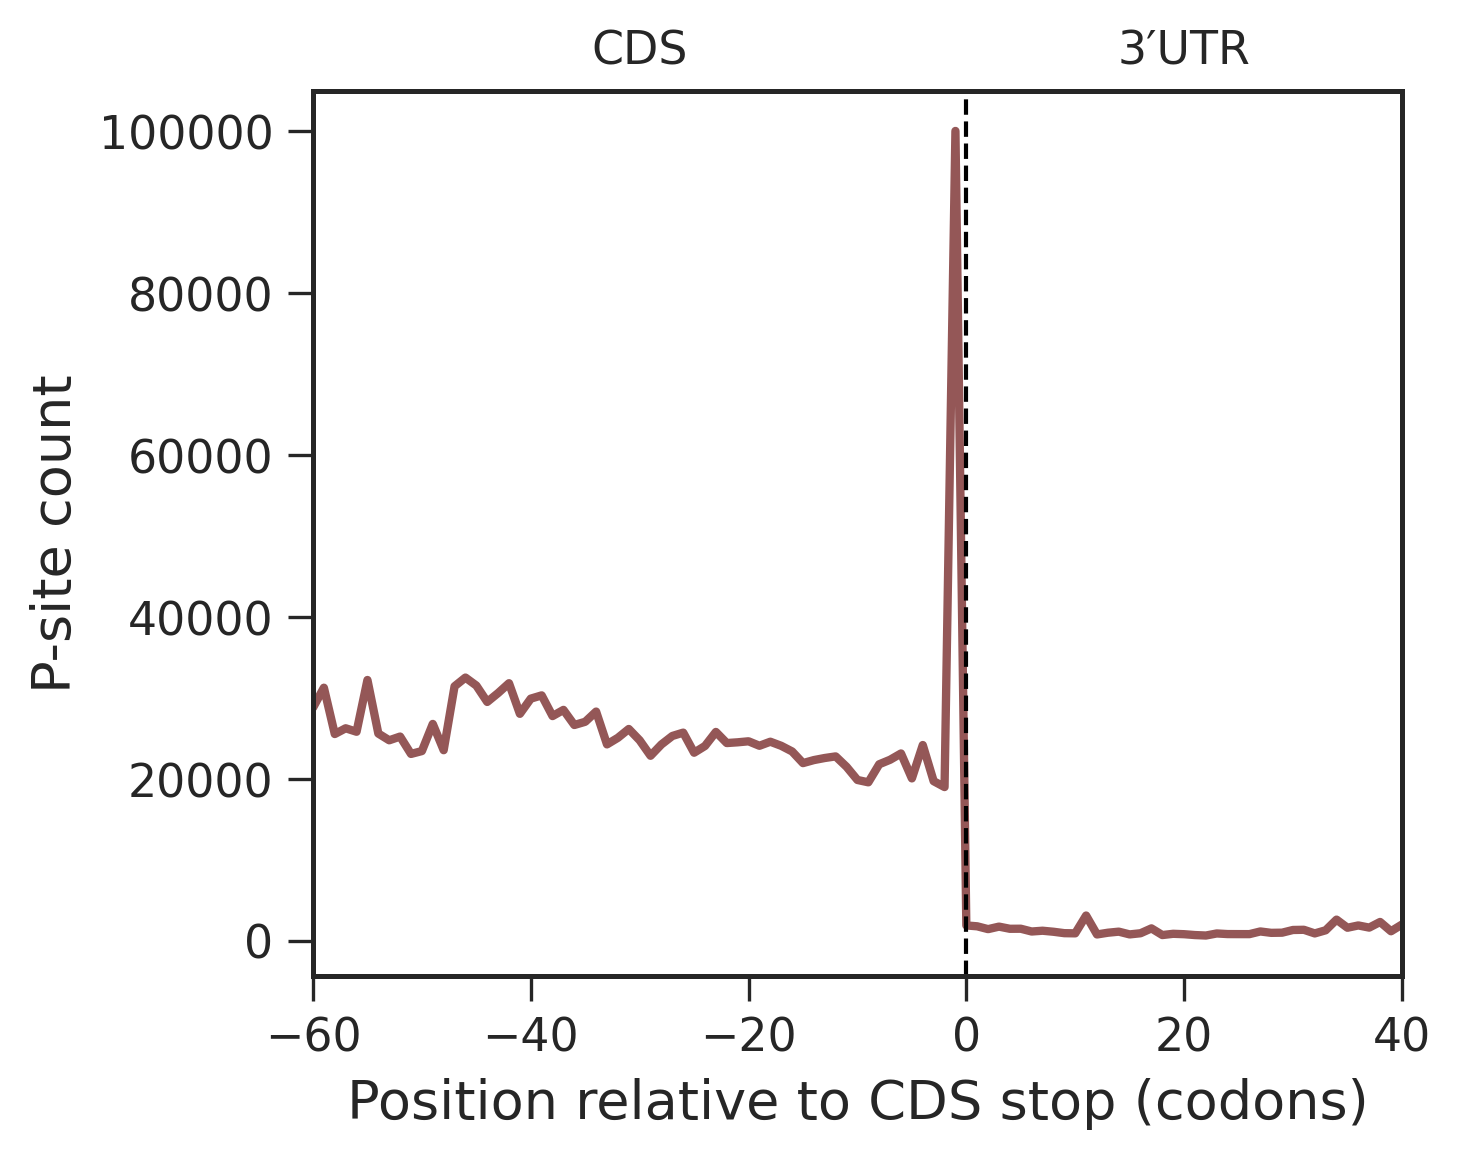

In [67]:
# ============================================
# 07.7 Stop-codon metagene
# ============================================

stop_metagene = (
    codon_coverage.loc[
        codon_coverage["from_cds_stop"].between(-60, 40)
    ]
    .groupby(
        "from_cds_stop",
        as_index=False,
    )["RIBO_FULL"]
    .sum()
    .rename(
        columns={
            "from_cds_stop": "Position",
            "RIBO_FULL": "P_sites",
        }
    )
)

display(stop_metagene.head())

fig, ax = make_fig(
    w=5,
    h=4,
)

ax.plot(
    stop_metagene["Position"],
    stop_metagene["P_sites"],
    color="#945757",
    linewidth=2,
)

ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

ax.set_xlim(-60, 40)

ax.set_xlabel(
    "Position relative to CDS stop (codons)"
)

ax.set_ylabel(
    "P-site count"
)

ax.text(
    -30,
    1.03,
    "CDS",
    transform=ax.get_xaxis_transform(),
    ha="center",
)

ax.text(
    20,
    1.03,
    "3′UTR",
    transform=ax.get_xaxis_transform(),
    ha="center",
)

plt.tight_layout()
plt.show()